## Clustering based on Subjects

In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from tslearn.clustering import TimeSeriesKMeans
from tslearn.metrics import cdist_dtw

In [2]:
candidate_paths = [
    Path("../dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("dataset/CMI_timeseries_preprocessed_outputs.pkl"),
    Path("CMI_timeseries_preprocessed_outputs.pkl"),
]

preprocessed_path = None

for path in candidate_paths:
    if path.exists():
        preprocessed_path = path
        break

if preprocessed_path is None:
    raise FileNotFoundError(
        "CMI_timeseries_preprocessed_outputs.pkl not found. "
        "Check the relative path from the current notebook."
    )

with open(preprocessed_path, "rb") as f:
    preprocessing_output = pickle.load(f)

print("Loaded:", preprocessed_path)
print("Available keys:")
for key in preprocessing_output.keys():
    print("-", key)

Loaded: ../dataset/CMI_timeseries_preprocessed_outputs.pkl
Available keys:
- CMI_timeseries_preprocessed
- CMI_timeseries_global_scaled
- CMI_timeseries_subject_scaled
- signal_cols
- id_col
- target_col
- target_df
- filtered_target_df
- non_wear_df
- hampel_summary_df


In [3]:
# Select the globally standardized time-series dataset
# IMPORTANT: this is NOT the window-level / subject-wise standardized dataset.

selected_source_name = "CMI_timeseries_global_scaled"

if selected_source_name not in preprocessing_output:
    raise KeyError(
        f"{selected_source_name} not found. "
        f"Available keys: {list(preprocessing_output.keys())}"
    )

ts_source = preprocessing_output[selected_source_name]

print("Selected source:", selected_source_name)
print("Type:", type(ts_source))
print("Length:", len(ts_source))
print("Shape:", getattr(ts_source, "shape", None))

Selected source: CMI_timeseries_global_scaled
Type: <class 'list'>
Length: 4310
Shape: None


In [4]:
metadata_key_candidates = [
    "filtered_target_df",
    "metadata_df",
    "CMI_timeseries_metadata_filtered",
]

metadata_df = None
used_metadata_key = None

for key in metadata_key_candidates:
    if key in preprocessing_output:
        metadata_df = preprocessing_output[key].copy()
        used_metadata_key = key
        break

if metadata_df is None:
    raise KeyError(
        "No filtered metadata found in preprocessing_output. "
        f"Available keys: {list(preprocessing_output.keys())}"
    )

print("Using metadata key:", used_metadata_key)
print("metadata_df shape:", metadata_df.shape)
print("metadata columns:")
print(metadata_df.columns.tolist())

if len(metadata_df) != len(ts_source):
    raise ValueError(
        f"Length mismatch: ts_source has {len(ts_source)} windows, "
        f"metadata_df has {len(metadata_df)} rows."
    )

Using metadata key: filtered_target_df
metadata_df shape: (4310, 3)
metadata columns:
['filtered_series_index', 'subject_id', 'target_value']


In [5]:
candidate_id_cols = ["id", "subject_id", "participant_id", "PCIAT_id"]
candidate_target_cols = ["sii_binary", "target", "sii", "label", "class"]

id_col = None
for col in candidate_id_cols:
    if col in metadata_df.columns:
        id_col = col
        break

target_col = None
for col in candidate_target_cols:
    if col in metadata_df.columns:
        target_col = col
        break

if id_col is None:
    raise KeyError(
        f"Could not find subject id column. Available columns: {metadata_df.columns.tolist()}"
    )

if target_col is None:
    print("No target column found. Clustering will be evaluated only internally.")
else:
    print("Using target column:", target_col)

print("Using subject id column:", id_col)
print("Number of unique subjects:", metadata_df[id_col].nunique())

No target column found. Clustering will be evaluated only internally.
Using subject id column: subject_id
Number of unique subjects: 375


In [10]:

signal_cols = ["X", "Y", "Z", "enmo", "anglez"]

print("Signal columns:", signal_cols)

if isinstance(ts_source, list):
    X_windows = []

    for i, ts_df in enumerate(ts_source):
        missing_cols = [col for col in signal_cols if col not in ts_df.columns]
        if missing_cols:
            raise KeyError(f"Window {i} is missing columns: {missing_cols}")

        X_windows.append(ts_df[signal_cols].to_numpy(dtype=float))

    X_windows = np.stack(X_windows, axis=0)

else:
    X_windows = np.asarray(ts_source, dtype=float)

    if X_windows.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {X_windows.shape}")

    # Expected orientation: (n_windows, n_timesteps, n_channels)
    # If it is (n_windows, n_channels, n_timesteps), transpose it.
    if X_windows.shape[1] == len(signal_cols) and X_windows.shape[2] != len(signal_cols):
        X_windows = np.transpose(X_windows, (0, 2, 1))

print("X_windows shape:", X_windows.shape)
print("Expected: (n_windows, n_timesteps, n_channels)")

Signal columns: ['X', 'Y', 'Z', 'enmo', 'anglez']
X_windows shape: (4310, 200, 5)
Expected: (n_windows, n_timesteps, n_channels)


In [11]:
# Replace inf with nan
X_windows = np.where(np.isfinite(X_windows), X_windows, np.nan)

# Impute missing values channel-wise using global median over all windows and time steps
for j, signal in enumerate(signal_cols):
    channel_values = X_windows[:, :, j]
    median_value = np.nanmedian(channel_values)

    if np.isnan(median_value):
        median_value = 0.0

    X_windows[:, :, j] = np.nan_to_num(
        X_windows[:, :, j],
        nan=median_value,
        posinf=median_value,
        neginf=median_value,
    )

print("Any NaN left?", np.isnan(X_windows).any())
print("Any inf left?", np.isinf(X_windows).any())

Any NaN left? False
Any inf left? False


In [12]:
subject_ids = metadata_df[id_col].values

unique_subjects = pd.Series(subject_ids).drop_duplicates().values

X_subject_list = []
subject_summary_rows = []

for subject in unique_subjects:
    idx = np.where(subject_ids == subject)[0]

    X_subject_mean = X_windows[idx].mean(axis=0)  # shape: (n_timesteps, n_channels)

    X_subject_list.append(X_subject_mean)

    row = {
        "subject_id": subject,
        "n_windows": len(idx),
    }

    if target_col is not None:
        target_values = metadata_df.iloc[idx][target_col].dropna().values

        if len(target_values) == 0:
            row["target"] = np.nan
        else:
            # If target is constant per subject, this returns that value.
            # If not, it uses the mode.
            row["target"] = pd.Series(target_values).mode().iloc[0]

    subject_summary_rows.append(row)

X_subject = np.stack(X_subject_list, axis=0)
subject_df = pd.DataFrame(subject_summary_rows)

print("X_subject shape:", X_subject.shape)
print("subject_df shape:", subject_df.shape)
display(subject_df.head())

if target_col is not None:
    print("\nTarget distribution at subject level:")
    print(subject_df["target"].value_counts(dropna=False))

X_subject shape: (375, 200, 5)
subject_df shape: (375, 2)


,subject_id,n_windows
0,2265,27
1,3042,29
2,1647,19
3,736,33
4,1044,29


In [13]:
selected_signals = signal_cols.copy()

selected_channel_indices = [
    signal_cols.index(sig) for sig in selected_signals
]

X_subject_dtw = X_subject[:, :, selected_channel_indices]

print("Selected signals:", selected_signals)
print("X_subject_dtw shape:", X_subject_dtw.shape)

Selected signals: ['X', 'Y', 'Z', 'enmo', 'anglez']
X_subject_dtw shape: (375, 200, 5)


In [14]:
# TimeSeriesKMeans with DTW and Sakoe-Chiba constraint

k_values = range(2, 9)
sakoe_chiba_radius_values = [5, 10, 20]

dtw_kmeans_results = []

for radius in sakoe_chiba_radius_values:
    for k in k_values:
        print(f"Fitting DTW KMeans | k={k}, Sakoe-Chiba radius={radius}")

        model = TimeSeriesKMeans(
            n_clusters=k,
            metric="dtw",
            metric_params={
                "global_constraint": "sakoe_chiba",
                "sakoe_chiba_radius": radius,
            },
            max_iter=20,
            n_init=3,
            random_state=42,
            verbose=False,
            n_jobs=-1,
        )

        labels = model.fit_predict(X_subject_dtw)

        # Compute precomputed DTW distance matrix for silhouette
        D = cdist_dtw(
            X_subject_dtw,
            X_subject_dtw,
            global_constraint="sakoe_chiba",
            sakoe_chiba_radius=radius,
            n_jobs=-1,
        )

        sil = silhouette_score(D, labels, metric="precomputed")

        result = {
            "k": k,
            "sakoe_chiba_radius": radius,
            "silhouette_dtw": sil,
            "inertia": model.inertia_,
        }

        if "target" in subject_df.columns and subject_df["target"].notna().any():
            valid_mask = subject_df["target"].notna().values

            if valid_mask.sum() > 0:
                result["ari_vs_target"] = adjusted_rand_score(
                    subject_df.loc[valid_mask, "target"],
                    labels[valid_mask],
                )
                result["nmi_vs_target"] = normalized_mutual_info_score(
                    subject_df.loc[valid_mask, "target"],
                    labels[valid_mask],
                )

        dtw_kmeans_results.append(result)

dtw_kmeans_results_df = pd.DataFrame(dtw_kmeans_results)

display(
    dtw_kmeans_results_df.sort_values(
        by="silhouette_dtw",
        ascending=False
    )
)

Fitting DTW KMeans | k=2, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=3, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=4, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=5, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=6, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=7, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=8, Sakoe-Chiba radius=5
Fitting DTW KMeans | k=2, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=3, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=4, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=5, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=6, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=7, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=8, Sakoe-Chiba radius=10
Fitting DTW KMeans | k=2, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=3, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=4, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=5, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=6, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=7, Sakoe-Chiba radius=20
Fitting DTW KMeans | k=8, Sakoe-Chiba radius=20

,k,sakoe_chiba_radius,silhouette_dtw,inertia
0,2,5,0.242169,585.196998
19,7,20,0.141322,370.730435
7,2,10,0.139096,565.405048
16,4,20,0.128071,431.603018
15,3,20,0.127242,465.242292
2,4,5,0.119835,505.234909
8,3,10,0.118124,514.871240
11,6,10,0.117068,446.299485
1,3,5,0.114466,541.969392
14,2,20,0.113036,524.822212


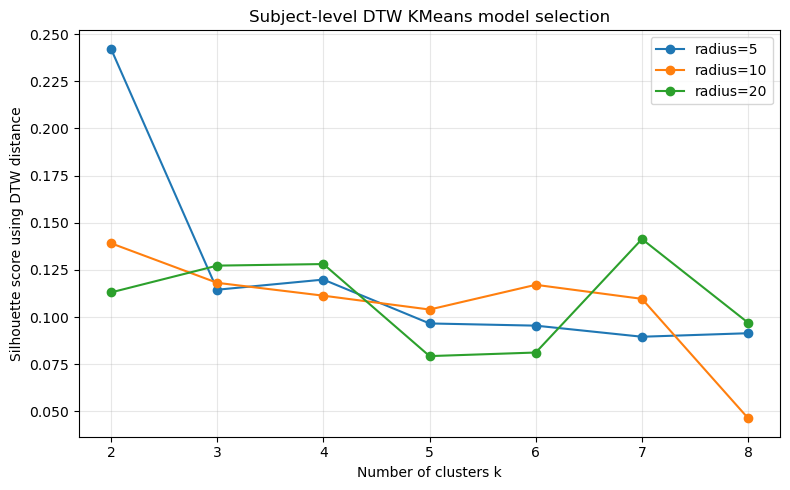

In [15]:
plt.figure(figsize=(8, 5))

for radius in sakoe_chiba_radius_values:
    tmp = dtw_kmeans_results_df[
        dtw_kmeans_results_df["sakoe_chiba_radius"] == radius
    ]

    plt.plot(
        tmp["k"],
        tmp["silhouette_dtw"],
        marker="o",
        label=f"radius={radius}"
    )

plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score using DTW distance")
plt.title("Subject-level DTW KMeans model selection")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
best_row = dtw_kmeans_results_df.sort_values(
    by="silhouette_dtw",
    ascending=False
).iloc[0]

best_k = int(best_row["k"])
best_radius = int(best_row["sakoe_chiba_radius"])

print("Best configuration:")
display(best_row)

final_dtw_kmeans = TimeSeriesKMeans(
    n_clusters=best_k,
    metric="dtw",
    metric_params={
        "global_constraint": "sakoe_chiba",
        "sakoe_chiba_radius": best_radius,
    },
    max_iter=50,
    n_init=5,
    random_state=42,
    verbose=True,
    n_jobs=-1,
)

subject_df["dtw_kmeans_cluster"] = final_dtw_kmeans.fit_predict(X_subject_dtw)

print("Cluster sizes:")
print(subject_df["dtw_kmeans_cluster"].value_counts().sort_index())

display(subject_df.head())

Best configuration:


k                       2.000000
sakoe_chiba_radius      5.000000
silhouette_dtw          0.242169
inertia               585.196998
Name: 0, dtype: float64

Init 1
665.730 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 375 out of 375 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 750 out of 750 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 750 out of 750 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBa

590.082 --> 

...

621.300 --> 

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 750 out of 750 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.0s


626.526 --> 626.526 --> 
Cluster sizes:
dtw_kmeans_cluster
0     56
1    319
Name: count, dtype: int64


[Parallel(n_jobs=-1)]: Done 750 out of 750 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 750 out of 750 | elapsed:    0.0s finished


,subject_id,n_windows,dtw_kmeans_cluster
0,2265,27,1
1,3042,29,1
2,1647,19,1
3,736,33,1
4,1044,29,1


In [17]:
if "target" in subject_df.columns and subject_df["target"].notna().any():
    print("Target distribution by DTW KMeans cluster:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"],
            normalize="index"
        )
    )

    print("Counts:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"]
        )
    )

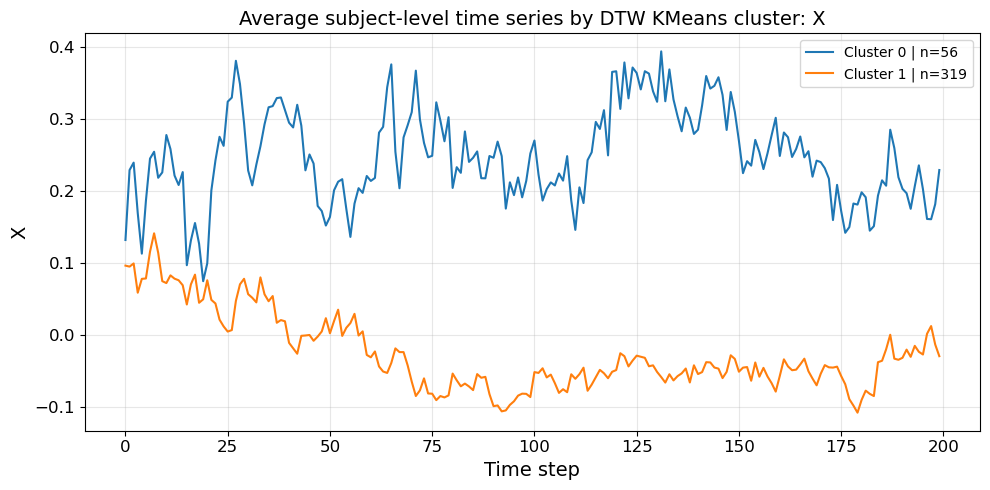

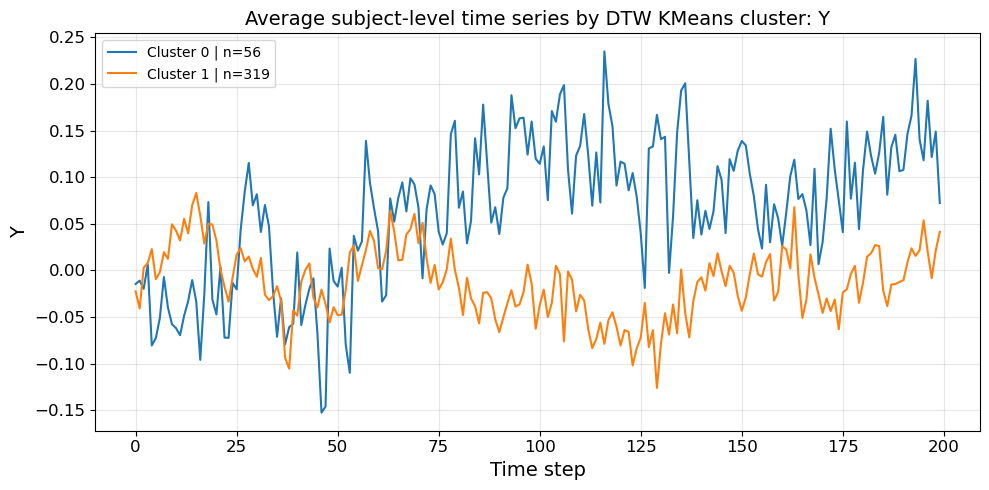

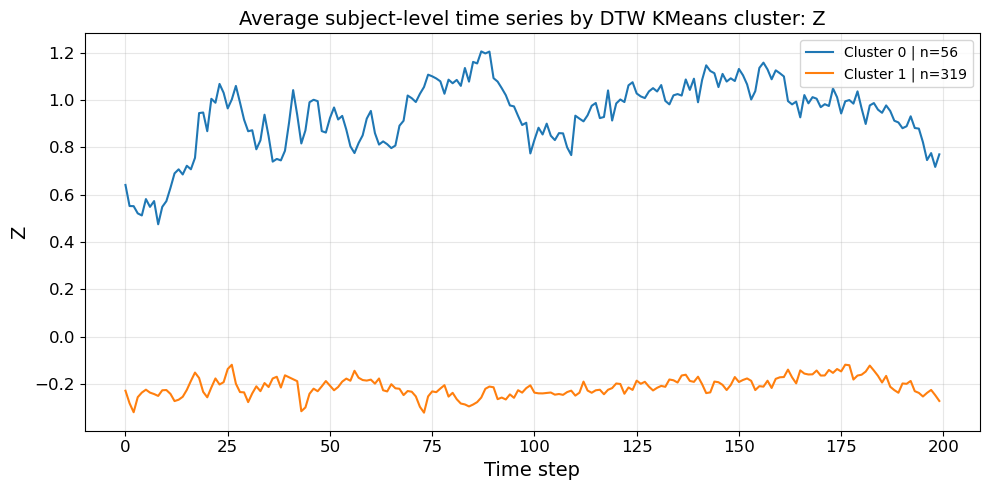

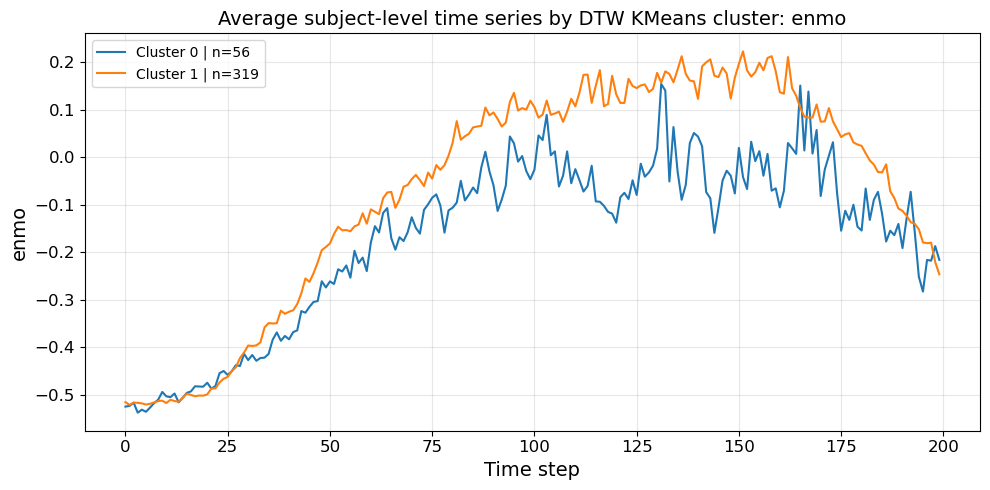

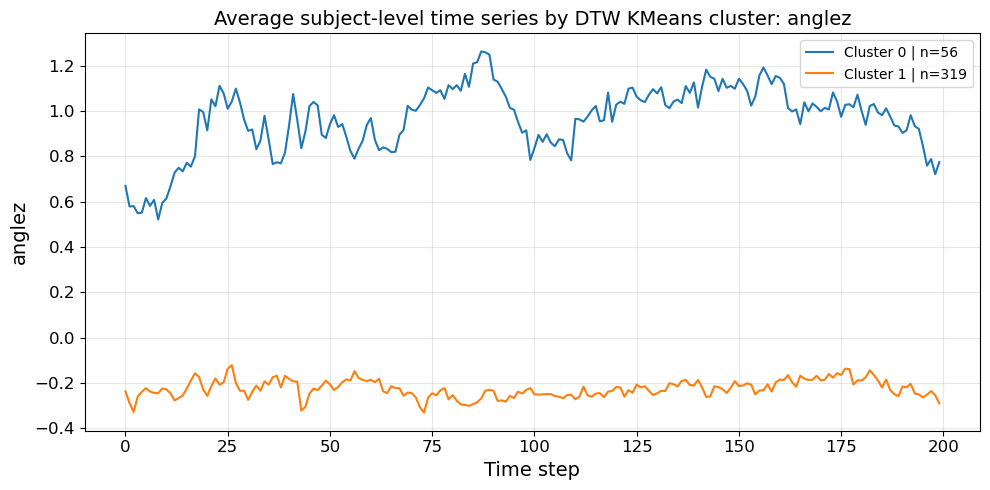

In [32]:
cluster_labels = subject_df["dtw_kmeans_cluster"].values
clusters = sorted(subject_df["dtw_kmeans_cluster"].unique())

for signal_idx, signal in enumerate(selected_signals):
    plt.figure(figsize=(10, 5))

    for cluster in clusters:
        cluster_mask = cluster_labels == cluster

        cluster_mean = X_subject_dtw[cluster_mask, :, signal_idx].mean(axis=0)

        plt.plot(
            cluster_mean,
            label=f"Cluster {cluster} | n={cluster_mask.sum()}"
        )

    plt.xlabel("Time step", fontsize=14)
    plt.ylabel(signal, fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(f"Average subject-level time series by DTW KMeans cluster: {signal}", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Explained variance ratio: [0.16912397 0.11539808]
Total explained variance: 0.2845220583247953


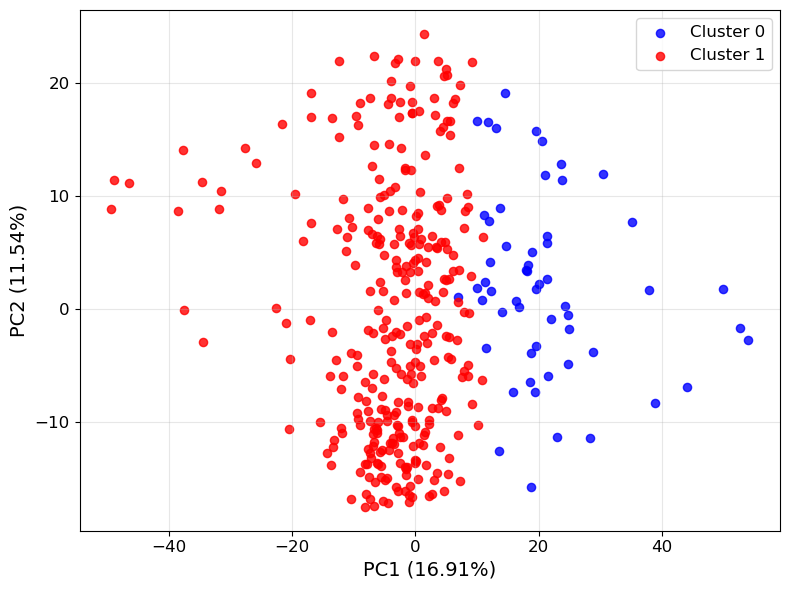

In [37]:
import matplotlib.colors as mcolors

X_subject_flat = X_subject_dtw.reshape(X_subject_dtw.shape[0], -1)

scaler = StandardScaler()
X_subject_flat_scaled = scaler.fit_transform(X_subject_flat)

pca = PCA(n_components=2, random_state=42)
X_subject_pca = pca.fit_transform(X_subject_flat_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

# Force cluster colors: cluster 0 = blue, cluster 1 = red
cluster_colors = {
    0: "blue",
    1: "red"
}

colors = subject_df["dtw_kmeans_cluster"].map(cluster_colors)

plt.figure(figsize=(8, 6))

for cluster in sorted(subject_df["dtw_kmeans_cluster"].unique()):
    mask = subject_df["dtw_kmeans_cluster"] == cluster
    
    plt.scatter(
        X_subject_pca[mask, 0],
        X_subject_pca[mask, 1],
        c=cluster_colors.get(cluster, "gray"),
        s=35,
        alpha=0.8,
        label=f"Cluster {cluster}"
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)", fontsize=14)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

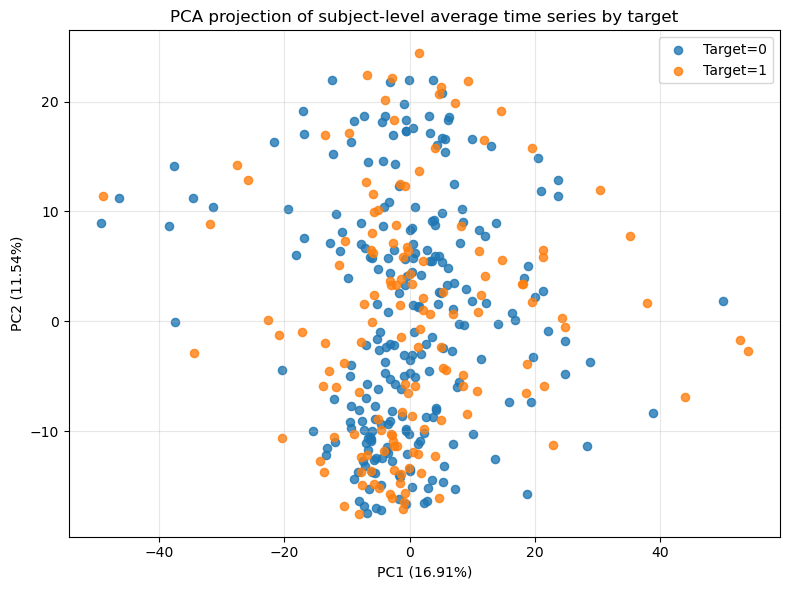

In [36]:
if "target" in subject_df.columns and subject_df["target"].notna().any():
    plt.figure(figsize=(8, 6))

    targets = sorted(subject_df["target"].dropna().unique())

    for target in targets:
        mask = subject_df["target"] == target

        plt.scatter(
            X_subject_pca[mask, 0],
            X_subject_pca[mask, 1],
            s=35,
            alpha=0.8,
            label=f"Target={target}"
        )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)")
    plt.title("PCA projection of subject-level average time series by target")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [22]:
if "target" in subject_df.columns and subject_df["target"].notna().any():
    print("Target distribution by DTW KMeans cluster:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"],
            normalize="index"
        )
    )

    print("Counts:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"]
        )
    )

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("subject_df columns before merge:")
print(subject_df.columns.tolist())

print("\nmetadata_df columns:")
print(metadata_df.columns.tolist())

# Detect subject id column in metadata_df
candidate_id_cols = [
    "subject_id",
    "id",
    "participant_id",
    "PCIAT_id"
]

metadata_id_col = None
for col in candidate_id_cols:
    if col in metadata_df.columns:
        metadata_id_col = col
        break

if metadata_id_col is None:
    raise KeyError(
        f"No subject id column found in metadata_df. "
        f"Available columns are: {metadata_df.columns.tolist()}"
    )

# Detect target column in metadata_df
candidate_target_cols = [
    "target",
    "target_value",
    "sii_binary",
    "sii",
    "label",
    "class"
]

metadata_target_col = None
for col in candidate_target_cols:
    if col in metadata_df.columns:
        metadata_target_col = col
        break

if metadata_target_col is None:
    raise KeyError(
        f"No target column found in metadata_df. "
        f"Available columns are: {metadata_df.columns.tolist()}"
    )

print("\nUsing metadata subject id column:", metadata_id_col)
print("Using metadata target column:", metadata_target_col)

# Build one target value per subject
# If a subject appears in multiple windows, we take the mode.
subject_target_df = (
    metadata_df[[metadata_id_col, metadata_target_col]]
    .dropna(subset=[metadata_id_col])
    .groupby(metadata_id_col)[metadata_target_col]
    .agg(lambda x: x.dropna().mode().iloc[0] if len(x.dropna()) > 0 else np.nan)
    .reset_index()
    .rename(columns={
        metadata_id_col: "subject_id",
        metadata_target_col: "target"
    })
)

print("\nsubject_target_df shape:", subject_target_df.shape)
display(subject_target_df.head())

# Avoid duplicate target column if you rerun the cell
if "target" in subject_df.columns:
    subject_df = subject_df.drop(columns=["target"])

# Merge target into subject_df
subject_df = subject_df.merge(
    subject_target_df,
    on="subject_id",
    how="left"
)

print("\nsubject_df columns after merge:")
print(subject_df.columns.tolist())

print("\nTarget distribution in subject_df:")
print(subject_df["target"].value_counts(dropna=False))

subject_df columns before merge:
['subject_id', 'n_windows', 'dtw_kmeans_cluster']

metadata_df columns:
['filtered_series_index', 'subject_id', 'target_value']

Using metadata subject id column: subject_id
Using metadata target column: target_value

subject_target_df shape: (375, 2)


,subject_id,target
0,3,1
1,25,0
2,63,1
3,68,0
4,85,1



subject_df columns after merge:
['subject_id', 'n_windows', 'dtw_kmeans_cluster', 'target']

Target distribution in subject_df:
target
0    236
1    139
Name: count, dtype: int64


In [30]:
#checking target distribution by cluster after merge
if "target" in subject_df.columns and subject_df["target"].notna().any():
    print("\nTarget distribution by DTW KMeans cluster after merge:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"],
            normalize="index"
        )
    )

    print("Counts:")
    display(
        pd.crosstab(
            subject_df["dtw_kmeans_cluster"],
            subject_df["target"]
        )
    )
    


Target distribution by DTW KMeans cluster after merge:


target,0,1
dtw_kmeans_cluster,,
0,0.571429,0.428571
1,0.639498,0.360502


Counts:


target,0,1
dtw_kmeans_cluster,,
0,32,24
1,204,115
